# ERD Modeling

In [1]:
import pandas as pd

In [2]:
coffee_sales = pd.read_excel('C:\\Users\\Adeeb\\Desktop\\Coffee-Shop-Sales-Management-System-Project\\Coffee Shop Sales.xlsx')

In [3]:
coffee_sales.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## 1st Normal Form

In [4]:
# Check 1: Check whether transaction_id is unique
coffee_sales['transaction_id'].is_unique

True

In [5]:
# Check 2: Find "Non-Atomic" values (e.g., strings with commas)
for column in coffee_sales.columns:
    if coffee_sales[column].dtype == 'str':  # Check only string columns
        non_atomic = coffee_sales[column].str.contains(',').any()
        print(f"Column '{column}' contains non-atomic values? {non_atomic}")


Column 'store_location' contains non-atomic values? False
Column 'product_category' contains non-atomic values? False
Column 'product_type' contains non-atomic values? False
Column 'product_detail' contains non-atomic values? False


## 2nd Normal Form

In [6]:
# No partial dependancies found as the primary key is a single column (transaction_id) and there are no composite keys.

## 3rd Normal Form

In [7]:
coffee_sales_grouped_1 =coffee_sales.groupby(['product_id', 'store_id'])['unit_price'].value_counts()
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(coffee_sales_grouped_1)

product_id  store_id  unit_price
1           3         18.00           47
            5         18.00           87
            8         18.00           75
2           3         18.00           46
            5         18.00           48
            8         18.00           89
3           3         14.75           51
            5         14.75           46
            8         14.75           72
4           3         20.45           46
            5         20.45           31
            8         20.45           73
5           3         15.00           57
            5         15.00           37
            8         15.00           54
6           3         21.00           75
            5         21.00           79
            8         21.00           64
7           3         19.75           51
            5         19.75           42
            8         19.75           53
8           3         45.00           45
            5         45.00           51
            8         45

In [8]:
coffee_sales['product_id'].nunique()

80

# Exploratory Data Analysis

## Missing Values

In [9]:
print(coffee_sales.isnull().sum())

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


## Negative Values

In [10]:
negative_qty = (coffee_sales['transaction_qty'] < 0).any()
negative_price = (coffee_sales['unit_price'] < 0).any()
negative_transaction_id = (coffee_sales['transaction_id'] < 0).any()
negative_store_id = (coffee_sales['store_id'] < 0).any()
negative_product_id = (coffee_sales['product_id'] < 0).any()
print(f"Negative values in 'transaction_qty'? {negative_qty}")
print(f"Negative values in 'unit_price'? {negative_price}") 
print(f"Negative values in 'transaction_id'? {negative_transaction_id}")
print(f"Negative values in 'store_id'? {negative_store_id}")
print(f"Negative values in 'product_id'? {negative_product_id}")

Negative values in 'transaction_qty'? False
Negative values in 'unit_price'? False
Negative values in 'transaction_id'? False
Negative values in 'store_id'? False
Negative values in 'product_id'? False


## Duplicate Values

In [11]:
duplicate_rows = coffee_sales.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [12]:
# Check for duplicates based on store_id, transaction_time, transaction_date, and product_id
columns_to_check = ['store_id', 'transaction_time', 'transaction_date', 'product_id']

duplicates = coffee_sales[coffee_sales.duplicated(subset=columns_to_check, keep=False)]

duplicates_sorted = duplicates.sort_values(by=columns_to_check)
duplicates_sorted = duplicates_sorted[['transaction_id', 'store_id', 'transaction_time', 'transaction_date','product_id']] 

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(duplicates_sorted)

        transaction_id  store_id transaction_time transaction_date  product_id
88690            88944         3         07:11:25       2023-05-09          39
88694            88948         3         07:11:25       2023-05-09          39
88696            88950         3         07:11:25       2023-05-09          39
88691            88945         3         07:11:25       2023-05-09          63
88693            88947         3         07:11:25       2023-05-09          63
122880          123217         3         07:11:25       2023-06-09          39
122884          123221         3         07:11:25       2023-06-09          39
122886          123223         3         07:11:25       2023-06-09          39
122881          123218         3         07:11:25       2023-06-09          63
122883          123220         3         07:11:25       2023-06-09          63
4976              5006         3         07:11:40       2023-01-10          71
4977              5007         3         07:11:40   

## Outliers

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

### Transaction Quantities

<Axes: title={'center': 'Distribution of Transaction Quantity'}, xlabel='transaction_qty'>

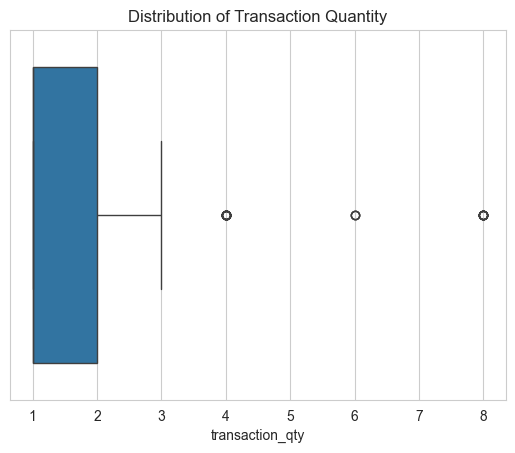

In [ ]:
sns.set_style("whitegrid")
plt.title('Distribution of Transaction Quantity')
sns.boxplot(x=coffee_sales['transaction_qty'])

In [22]:
coffee_sales[coffee_sales['transaction_qty'] >  3]

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
4163,4193,2023-01-08,12:58:32,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup
4352,4382,2023-01-08,19:32:15,4,5,Lower Manhattan,64,0.80,Flavours,Regular syrup,Hazelnut syrup
9310,9340,2023-01-17,09:05:20,8,8,Hell's Kitchen,8,45.00,Coffee beans,Premium Beans,Civet Cat
9365,9395,2023-01-17,09:55:47,8,8,Hell's Kitchen,8,45.00,Coffee beans,Premium Beans,Civet Cat
16490,16520,2023-01-30,08:49:26,4,5,Lower Manhattan,83,14.00,Branded,Housewares,I Need My Bean! Latte cup
21416,21473,2023-02-08,10:41:55,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup
21532,21589,2023-02-08,12:58:32,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup
38494,38601,2023-03-08,10:01:24,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup
38550,38657,2023-03-08,10:41:55,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup
38707,38814,2023-03-08,13:38:14,4,5,Lower Manhattan,64,0.80,Flavours,Regular syrup,Hazelnut syrup


Several Outliers were revealed but it can't be considered unusual as there may be instances of bulk orders ranging upto 8 units, hence these outliers shouldn't be removed as it would lead to a loss of legititmate transactions.

### Unit Price